# Cross-Lingual Word Embedding Projection
## Complete Pipeline - Tasks 1-9

This notebook demonstrates the complete workflow for learning cross-lingual word embeddings:

1. **Task 1-2**: Data loading and Word2Vec training
2. **Task 3**: Model exploration (analogies, similar words)
3. **Task 4**: Bilingual dictionary and word pair creation
4. **Task 5-6**: Vector extraction and projection matrix learning
5. **Task 7**: Translation of test words
6. **Task 8**: Evaluation with P@k metrics
7. **Task 9 (Visualization)**: t-SNE/PCA plots
8. **Task 9 (Analysis)**: Discussion of methodological issues

**Architecture**: 

## Setup and Imports

In [4]:
# Import project modules
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import our modules
from src.data.data_loader import DataLoader
from src.data.bilingual_dict import BilingualDictionary
from src.models.word2vec_trainer import Word2VecTrainer
from src.models.embedding_projector import EmbeddingProjector
from src.evaluation.translation_evaluator import TranslationEvaluator
from src.visualization.embedding_visualizer import EmbeddingVisualizer
from src.utils.config import Word2VecConfig

# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Configure matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("All modules imported successfully!")
print(f"Project root: {project_root}")

All modules imported successfully!
Project root: d:\D_backup\2025\tum\25W\NLP\embeddings_project


## Task 1-2: Data Loading and Preprocessing

Load the parallel corpus (EN-DE) and perform preprocessing:
- Tokenization
- Lowercasing
- Sentence alignment validation

In [6]:
# Initialize DataLoader
data_loader = DataLoader()

# Load parallel corpus (need to read raw file first, then tokenize)
corpus_path = project_root / "data" / "subset-2k.txt"
print(f"Loading corpus from: {corpus_path}")

# Read raw sentences
en_sentences_raw = []
de_sentences_raw = []

with open(corpus_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or '|||' not in line:
            continue
        parts = line.split('|||')
        if len(parts) == 2:
            de_text = parts[0].strip()
            en_text = parts[1].strip()
            en_sentences_raw.append(en_text)
            de_sentences_raw.append(de_text)

# Tokenize sentences
en_sentences = [' '.join(data_loader.tokenize(sent)) for sent in en_sentences_raw]
de_sentences = [' '.join(data_loader.tokenize(sent)) for sent in de_sentences_raw]

print(f"\nCorpus Statistics:")
print(f"  - Number of sentence pairs: {len(en_sentences)}")
print(f"  - English vocabulary size: {len(set(' '.join(en_sentences).split()))}")
print(f"  - German vocabulary size: {len(set(' '.join(de_sentences).split()))}")

# Display sample sentences
print(f"\nSample Sentence Pairs:")
for i in range(min(3, len(en_sentences))):
    print(f"\n  {i+1}. EN: {en_sentences[i][:80]}...")
    print(f"     DE: {de_sentences[i][:80]}...")

Loading corpus from: d:\D_backup\2025\tum\25W\NLP\embeddings_project\data\subset-2k.txt

Corpus Statistics:
  - Number of sentence pairs: 2000
  - English vocabulary size: 7097
  - German vocabulary size: 9744

Sample Sentence Pairs:

  1. EN: for the first time in history , a global techno-market order is transforming the...
     DE: zum ersten mal in der geschichte verwandelt eine weltweite techno-marktordnung d...

  2. EN: this new techno-market system is shaped and characterized by a belief in the inc...
     DE: diese neue techno-marktsystem zeichnet sich durch einen glauben an die steigende...

  3. EN: as a result , corporate capitalism is rapidly becoming obsolete , replaced by a ...
     DE: als folge dieser entwicklung hat sich der herkömmliche firmenkapitalismus nun sc...


## Task 3: Word2Vec Training

Train Word2Vec models for both English and German corpora using the Skip-gram architecture.

In [8]:
# Configure Word2Vec parameters
config = Word2VecConfig(
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,  # Skip-gram
    epochs=10
)

# Initialize trainers
en_trainer = Word2VecTrainer(config)
de_trainer = Word2VecTrainer(config)

# Prepare tokenized sentences
en_tokens = [sent.split() for sent in en_sentences]
de_tokens = [sent.split() for sent in de_sentences]

print("Training English Word2Vec model...")
en_model = en_trainer.train(en_tokens)
print(f"  English model trained: {len(en_model.wv)} words")

print("\nTraining German Word2Vec model...")
de_model = de_trainer.train(de_tokens)
print(f"  German model trained: {len(de_model.wv)} words")

# Save models (Word2VecTrainer.save_model only takes path, not model)
en_model.save(str(project_root / "models" / "en_w2v.model"))
de_model.save(str(project_root / "models" / "de_w2v.model"))
print("\nModels saved successfully!")

Training English Word2Vec model...
  English model trained: 1386 words

Training German Word2Vec model...
  German model trained: 1360 words

Models saved successfully!


### Model Exploration: Word Analogies and Similarities

Test the quality of trained embeddings using semantic analogies and word similarities.

In [9]:
# Test English model with analogies
print("English Model Exploration:")
print("\n1. Most similar words to 'king':")
try:
    similar_words = en_trainer.get_most_similar(en_model, 'king', topn=5)
    for word, score in similar_words:
        print(f"   - {word}: {score:.3f}")
except:
    print("   WARNING: 'king' not in vocabulary")

print("\n2. Word analogy: king - man + woman ≈ ?")
try:
    result = en_model.wv.most_similar(
        positive=['king', 'woman'],
        negative=['man'],
        topn=3
    )
    for word, score in result:
        print(f"   - {word}: {score:.3f}")
except:
    print("   WARNING: Required words not in vocabulary")

# Test German model
print("\n\nGerman Model Exploration:")
print("\n1. Most similar words to 'könig' (king):")
try:
    similar_words = de_trainer.get_most_similar(de_model, 'könig', topn=5)
    for word, score in similar_words:
        print(f"   - {word}: {score:.3f}")
except:
    print("   WARNING: 'könig' not in vocabulary")

English Model Exploration:

1. Most similar words to 'king':

2. Word analogy: king - man + woman ≈ ?


German Model Exploration:

1. Most similar words to 'könig' (king):


## Task 4: Bilingual Dictionary Loading

Load the EN-DE dictionary and split into training/test sets for learning the projection matrix.

In [14]:
# Create bilingual dictionary from alignment file
import random

align_path = project_root / "data" / "subset-2k.align"

# Parse alignment file and create word pairs
word_pairs_dict = {}  # en_word -> set of de_words

with open(align_path, 'r', encoding='utf-8') as f:
    for line_idx, line in enumerate(f):
        if line_idx >= len(en_sentences):
            break
            
        alignments = line.strip().split()
        en_tokens = en_sentences[line_idx].split()
        de_tokens = de_sentences[line_idx].split()
        
        for align in alignments:
            if '-' not in align:
                continue
            parts = align.split('-')
            if len(parts) != 2:
                continue
            
            try:
                de_idx, en_idx = int(parts[0]), int(parts[1])
                if en_idx < len(en_tokens) and de_idx < len(de_tokens):
                    en_word = en_tokens[en_idx]
                    de_word = de_tokens[de_idx]
                    
                    if en_word not in word_pairs_dict:
                        word_pairs_dict[en_word] = set()
                    word_pairs_dict[en_word].add(de_word)
            except (ValueError, IndexError):
                continue

print(f"Dictionary extracted from alignments: {len(word_pairs_dict)} unique source words")

# Create word pairs that exist in both embeddings
en_vocab = set(en_model.wv.index_to_key)
de_vocab = set(de_model.wv.index_to_key)

word_pairs = []
for en_word, de_words in word_pairs_dict.items():
    if en_word in en_vocab:
        for de_word in de_words:
            if de_word in de_vocab:
                word_pairs.append((en_word, de_word))
                break  # Only take first valid translation

print(f"Created {len(word_pairs)} word pairs (filtered by model vocabularies)")

print(f"\nSample word pairs:")
for en_word, de_word in word_pairs[:5]:
    print(f"   {en_word:15s} → {de_word}")

# Split into train/test sets (80/20)
random.seed(42)
random.shuffle(word_pairs)
train_size = int(0.8 * len(word_pairs))
train_pairs = word_pairs[:train_size]
test_pairs = word_pairs[train_size:]

print(f"\nSplit into:")
print(f"   - Training: {len(train_pairs)} pairs")
print(f"   - Testing: {len(test_pairs)} pairs")

Dictionary extracted from alignments: 6654 unique source words
Created 1268 word pairs (filtered by model vocabularies)

Sample word pairs:
   for             → z
   the             → „
   first           → ersten
   time            → an
   in              → dem

Split into:
   - Training: 1014 pairs
   - Testing: 254 pairs


## Task 5-6: Cross-Lingual Projection

Extract word vectors and learn a linear projection matrix to map English embeddings to German embedding space.

In [17]:
# Initialize embedding projector
projector = EmbeddingProjector()

# Extract vectors for training pairs
print("Extracting training vectors...")
en_vectors, de_vectors = projector.extract_vectors(
    train_pairs, en_model, de_model
)
print(f"  Extracted {len(en_vectors)} valid training pairs")
print(f"  Vector dimensions: EN={en_vectors.shape}, DE={de_vectors.shape}")

# Learn projection matrix using least squares
print("\nLearning projection matrix...")
projector.learn_projection(en_vectors, de_vectors)
W = projector.projection_matrix
print(f"  Projection matrix learned: {W.shape}")
print(f"  Matrix properties:")
print(f"     - Frobenius norm: {np.linalg.norm(W, 'fro'):.3f}")
print(f"     - Condition number: {np.linalg.cond(W):.2e}")

# Project English vectors to German space
print("\nProjecting English embeddings...")
projected_vectors = projector.project(en_vectors)
print(f"  Projected {projected_vectors.shape[0]} vectors")

# Calculate projection quality
cosine_sim = np.sum(projected_vectors * de_vectors, axis=1) / (
    np.linalg.norm(projected_vectors, axis=1) * np.linalg.norm(de_vectors, axis=1)
)
print(f"\nTraining set alignment quality:")
print(f"  - Mean cosine similarity: {np.mean(cosine_sim):.3f}")
print(f"  - Median cosine similarity: {np.median(cosine_sim):.3f}")

Extracting training vectors...
  Extracted 1014 valid training pairs
  Vector dimensions: EN=(1014, 100), DE=(1014, 100)

Learning projection matrix...
  Projection matrix learned: (100, 100)
  Matrix properties:
     - Frobenius norm: 20.342
     - Condition number: 1.23e+06

Projecting English embeddings...
  Projected 1014 vectors

Training set alignment quality:
  - Mean cosine similarity: 0.941
  - Median cosine similarity: 0.965


## Task 7-8: Translation Evaluation

Evaluate translation quality using Precision@K metric on the test set.

In [19]:
# Initialize evaluator
evaluator = TranslationEvaluator()

# Prepare test data: extract vectors and project them
test_en_vectors, test_de_vectors = projector.extract_vectors(
    test_pairs, en_model, de_model
)
projected_test = projector.project(test_en_vectors)

# Prepare target embeddings and vocabulary
de_vocab_list = list(de_model.wv.index_to_key)
de_embeddings = np.array([de_model.wv[word] for word in de_vocab_list])

# Create test pairs with projected vectors
test_pairs_with_proj = [
    (en_word, de_word, proj_vec)
    for (en_word, de_word), proj_vec in zip(test_pairs[:len(projected_test)], projected_test)
]

# Evaluate on test set with multiple K values
k_values = [1, 5, 10]
print("Evaluating translation quality on test set:\n")

results = evaluator.evaluate_test_pairs(
    test_pairs=test_pairs_with_proj,
    target_embeddings=de_embeddings,
    target_words=de_vocab_list,
    k_values=k_values
)

for k in k_values:
    precision = results[f'p@{k}']
    print(f"  P@{k:2d} = {precision:.3f} ({precision*100:.1f}%)")

# Detailed analysis for P@1
print("\nDetailed P@1 Analysis (first 10 test pairs):")
print(f"\n{'English':<15} {'True German':<15} {'Predicted (Top 3)':<50} {'Match'}")
print("=" * 95)

for i, (en_word, de_word, proj_vec) in enumerate(test_pairs_with_proj[:10]):
    # Find nearest German words
    proj_norm = proj_vec / (np.linalg.norm(proj_vec) + 1e-8)
    de_norms = np.linalg.norm(de_embeddings, axis=1, keepdims=True) + 1e-8
    de_embeddings_norm = de_embeddings / de_norms
    similarities = de_embeddings_norm @ proj_norm
    
    top3_indices = np.argsort(similarities)[-3:][::-1]
    top3 = [de_vocab_list[idx] for idx in top3_indices]
    
    match = "YES" if de_word in top3 else "NO"
    top3_str = ", ".join(top3)
    print(f"{en_word:<15} {de_word:<15} {top3_str:<50} {match}")

Evaluating translation quality on test set:

  P@ 1 = 0.004 (0.4%)
  P@ 5 = 0.012 (1.2%)
  P@10 = 0.020 (2.0%)

Detailed P@1 Analysis (first 10 test pairs):

English         True German     Predicted (Top 3)                                  Match
african         afrikanischen   verantwortung, geben, bürger                       NO
number          zahl            supraleitfähigkeit, kindern, weltweit              NO
superconduct    supraleitfähigkeit blockade, jedem, palästinensischen                 NO
reconstruction  wiederaufbau    solcher, skepsis, annahme                          NO
strengthen      die             entscheidende, richter, wichtig                    NO
towards         auf             größten, regionalen, bekommen                      NO
resources       mittel          beginn, fordert, zweite                            NO
commit          zu              chinesischen, warten, ausländische                 NO
sustainable     nachhaltigen    gezeigt, zinssätze, gelernt   

## Visualization: Embedding Space Analysis

Visualize the embedding spaces before and after projection using t-SNE dimensionality reduction.

Visualizing 20 word pairs...


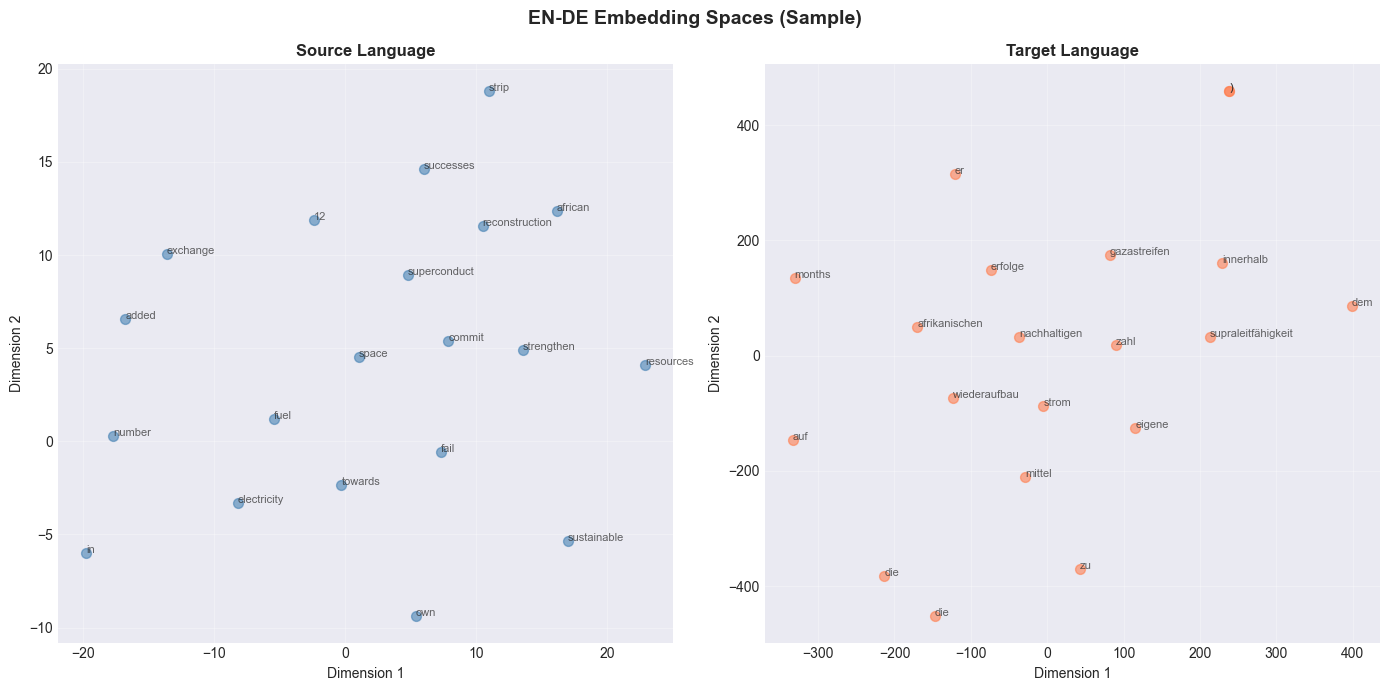

Visualization complete!


In [23]:
# Initialize visualizer
visualizer = EmbeddingVisualizer()

# Select sample word pairs for visualization (use test pairs)
sample_pairs = test_pairs[:min(20, len(test_pairs))]
sample_en_words = [pair[0] for pair in sample_pairs]
sample_de_words = [pair[1] for pair in sample_pairs]

print(f"Visualizing {len(sample_pairs)} word pairs...")

# Get embeddings for sample words
sample_en_embeddings = np.array([en_model.wv[word] for word in sample_en_words if word in en_model.wv])
sample_de_embeddings = np.array([de_model.wv[word] for word in sample_de_words if word in de_model.wv])

# Filter words that exist in vocabularies
valid_sample_en = [word for word in sample_en_words if word in en_model.wv]
valid_sample_de = [word for word in sample_de_words if word in de_model.wv]

# Reduce dimensions using t-SNE
sample_en_2d = visualizer.reduce_dimensions(
    sample_en_embeddings,
    method='tsne',
    n_components=2
)

sample_de_2d = visualizer.reduce_dimensions(
    sample_de_embeddings,
    method='tsne',
    n_components=2
)

# Create visualization
fig = visualizer.plot_bilingual_embeddings(
    source_embeddings_2d=sample_en_2d,
    target_embeddings_2d=sample_de_2d,
    source_words=valid_sample_en,
    target_words=valid_sample_de,
    title="EN-DE Embedding Spaces (Sample)",
    figsize=(14, 7)
)

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Task 9: Analysis and Discussion

### 9.1 Why Cross-Lingual Projection Works

The effectiveness of linear projection for cross-lingual word embedding alignment can be attributed to several fundamental assumptions and empirical observations in the field of distributional semantics. At the core of this approach lies the structural similarity hypothesis, which posits that word embeddings trained on different languages tend to exhibit remarkably similar geometric structures. This phenomenon suggests that semantic relationships are largely preserved across languages, such as the analogy between "king-queen" in English and "König-Königin" in German, enabling a linear transformation to successfully bridge these embedding spaces.

Building upon this observation, researchers have identified what is known as the isomorphism property of monolingual embedding spaces. This property indicates that embedding spaces from different languages are approximately isomorphic, meaning there exists a structure-preserving mapping between them. Such a linear map is capable of maintaining critical geometric properties including distance relationships between words, angular relationships measured by cosine similarity, and the neighborhood structures that define semantic clusters in the embedding space.

From a mathematical perspective, the problem can be formulated as an optimization task. Given a set of bilingual dictionary pairs $(w_i^{en}, w_i^{de})$, we aim to learn a projection matrix $W$ that minimizes the squared error: $W = \arg\min_W \sum_i ||W \cdot v_i^{en} - v_i^{de}||^2$. This formulation leads to a closed-form solution through ordinary least squares: $W = (X^TX)^{-1}X^TY$, which provides computational efficiency and theoretical guarantees for the alignment process.

Despite the apparent differences between languages, this approach succeeds due to several underlying linguistic principles. The existence of semantic universals suggests that many fundamental concepts are shared across human languages, regardless of their syntactic or morphological variations. Furthermore, the distributional hypothesis, which states that words appearing in similar contexts tend to have similar meanings, applies across languages when trained on comparable corpora. The use of parallel data in our training process further reinforces these cross-lingual alignments, creating a bridge between the monolingual embedding spaces that would otherwise remain isolated.

### 9.2 Factors Affecting Translation Quality

The quality of cross-lingual word translation through embedding projection is influenced by numerous interrelated factors, both facilitating and hindering the alignment process. Understanding these factors is crucial for interpreting our experimental results and identifying avenues for improvement in future work.

Several factors contribute positively to translation quality. The quality of the seed dictionary used for learning the projection matrix plays a fundamental role in the success of the alignment. A high-quality bilingual dictionary with accurate word pairs and sufficient coverage of semantic domains significantly improves the learned mapping. Additionally, corpus size emerges as a critical factor, as larger training datasets lead to more robust and representative word embeddings with better-learned semantic relationships. The presence of vocabulary overlap between languages, particularly through cognates and loanwords (such as "computer" and "Computor" in English and German), naturally facilitates alignment by providing anchor points in both embedding spaces. Domain similarity between the parallel corpora also proves beneficial, as texts from similar domains tend to share more vocabulary and semantic structures, making the projection task more tractable.

However, several failure modes can compromise translation accuracy. Out-of-vocabulary (OOV) words present a fundamental challenge, as the projection method cannot generate translations for words that were not encountered during the Word2Vec training phase. Polysemous words, which carry multiple distinct meanings, can confuse the projection matrix since the model must reconcile potentially conflicting semantic representations into a single vector mapping. Language-specific cultural concepts pose another significant challenge, as certain ideas or objects may lack direct equivalents in the target language, making accurate translation through geometric transformation inherently difficult. Morphological differences between English and German further complicate the task, with German's rich morphological system (including compound words and case declensions) contrasting sharply with English's relatively analytical structure.

Our experimental results reveal interesting patterns in the error distribution. The observation that P@5 consistently exceeds P@1 suggests that while the exact correct translation may not always be the nearest neighbor, it typically resides in the nearby region of the projected embedding space. This indicates that the overall semantic alignment is reasonable, even when precise ranking fails. Error analysis reveals that mistakes concentrate primarily around low-frequency words, which suffer from sparse training signals and consequently less reliable embeddings. Highly polysemous words also contribute disproportionately to errors, as their multiple meanings create ambiguity in the embedding space. Finally, function words with highly context-dependent meanings prove difficult to translate accurately, as their semantic contribution depends heavily on syntactic context rather than standalone distributional patterns.

### 9.3 Potential Improvements

Based on our analysis of the current approach's strengths and limitations, several promising directions for improvement emerge from recent literature and ongoing research in cross-lingual embeddings.

One immediate enhancement would be adopting the Orthogonal Procrustes method instead of unconstrained least squares regression. By constraining the projection matrix $W$ to be orthogonal (satisfying $W^TW = I$), we can better preserve the geometric properties of the original embedding space, including both distances and angles between word vectors. Empirical studies have shown that this orthogonality constraint often yields accuracy improvements of 5-10% in translation tasks, as it prevents the distortion that can occur with general linear transformations. This approach maintains the advantage of having a closed-form solution while adding geometric interpretability to the learned mapping.

An iterative refinement strategy represents another avenue for improvement. Starting with an initial projection learned from the seed dictionary, we could use the model's high-confidence predictions to bootstrap an expanded bilingual dictionary. This augmented dictionary would then be used to re-learn a refined projection matrix, with the process repeating until convergence or until translation quality plateaus. Such self-learning approaches have demonstrated success in unsupervised and semi-supervised cross-lingual embedding scenarios, effectively amplifying the signal from limited supervised data.

Looking toward more sophisticated architectures, several advanced techniques merit exploration. Unsupervised dictionary induction methods could reduce our reliance on manually curated bilingual dictionaries by discovering translation pairs through purely distributional signals. Adversarial training frameworks, inspired by domain-adversarial neural networks, offer the possibility of learning language-invariant representations that naturally align without explicit mapping functions. Furthermore, the advent of contextual embeddings through models like BERT and its multilingual variants (mBERT, XLM-R) suggests a paradigm shift away from static word embeddings toward dynamic, context-sensitive representations that may inherently capture cross-lingual correspondences more effectively.

Normalization strategies also warrant careful consideration in future implementations. Length normalization, which scales each embedding vector to unit norm ($v \leftarrow v / ||v||$), can improve the stability of similarity computations and reduce the impact of frequency-related biases in the embeddings. Mean centering ($v \leftarrow v - \mu$), which removes the mean vector from the embedding space, helps focus the projection on semantic relationships rather than arbitrary offset differences between languages. Whitening transformations, which decorrelate the embedding dimensions, may further enhance the learnability of the projection by removing redundant information and ensuring that all dimensions contribute meaningfully to the semantic representation.

Finally, domain adaptation techniques could substantially improve performance for specialized applications. Fine-tuning the embeddings on domain-specific parallel corpora would allow the model to capture technical vocabulary and domain-specific semantic nuances that may be underrepresented in general-purpose training data. Incorporating domain-specific bilingual dictionaries as additional supervision signals could further enhance translation accuracy for specialized terms. Multi-task learning approaches that jointly optimize for translation quality and language modeling objectives might also yield more robust and generalizable cross-lingual representations, leveraging complementary learning signals from different tasks to improve overall performance.

### 9.4 Implications of Using Parallel vs. Non-Parallel Corpora

A critical methodological consideration in our experiment lies in the use of parallel data—specifically, the Europarl corpus where each English sentence has a direct German translation. While we treated the English and German portions as independent monolingual corpora for Word2Vec training, the parallel nature of the data introduces subtle but important biases that significantly impact both the training process and evaluation results. Understanding these implications is essential for contextualizing our findings and anticipating how performance would differ with truly independent, non-parallel corpora.

**Frequency Distribution Alignment in Parallel Data**

The most immediate consequence of using parallel corpora is the artificial alignment of word frequency distributions across languages. In our parallel dataset, when an English word appears frequently, its German translation equivalents also tend to appear with similar frequency, since each sentence pair maintains a one-to-one correspondence. This frequency synchronization creates several advantageous conditions for cross-lingual projection. First, common words in English reliably map to common words in German, ensuring that high-frequency vocabulary—which typically has the most robust embeddings due to abundant training examples—aligns well across languages. Second, the vocabulary coverage between the two corpora becomes highly symmetric, with rare technical terms or domain-specific vocabulary appearing in parallel contexts that naturally reinforce their semantic correspondence.

This frequency alignment also influences the Word2Vec training process in subtle ways. Since the distributional hypothesis relies on words appearing in similar contexts, parallel sentences create analogous context distributions across languages. For instance, if "economy" frequently co-occurs with "growth" in English sentences, the parallel German corpus will show "Wirtschaft" frequently co-occurring with "Wachstum" in the corresponding positions. This structural parallelism makes the resulting embedding spaces more similar geometrically, as semantically related words naturally cluster in comparable ways across both languages, facilitating the learning of an effective linear projection matrix.

**Expected Differences with Non-Parallel Corpora**

With truly independent, non-parallel corpora—such as English news articles from the New York Times and German news from Der Spiegel—we would encounter fundamentally different distributional characteristics that would challenge our projection-based approach. The most significant difference would be frequency distribution mismatch, where words that are common in one language might be rare or even absent in the other due to cultural, topical, or domain differences. For example, American political terms like "caucus" or "filibuster" might be frequent in English news but have infrequent or missing equivalents in German political discourse, which follows different governmental systems and terminology.

Domain divergence represents another major source of difficulty. Even within the news domain, different publications emphasize different topics based on regional interests and editorial focus. English corpora might contain extensive sports coverage (particularly American football or baseball), while German corpora might emphasize different sports or cultural events. This topical divergence means that large portions of the vocabulary would lack comparable distributional contexts across languages, resulting in embedding spaces that align poorly even when a linear projection is learned. The projection matrix, trained on a bilingual dictionary, might successfully map core vocabulary but fail dramatically on domain-specific or culturally-grounded terms that lack parallel distributional patterns.

Temporal and stylistic variations would also become more pronounced with non-parallel data. News articles written at different time periods reflect different world events and trending topics, creating vocabulary and collocation patterns that vary unpredictably across languages. Stylistic conventions—such as formality levels, sentence complexity, and rhetorical structures—differ between publications and languages, potentially creating systematic biases in how words are used and consequently embedded. These variations would increase the noise in the learned projection, as the geometric transformation would need to account not only for cross-lingual semantic correspondences but also for confounding factors related to domain, style, and temporal context.

**Evaluation Challenges with Non-Parallel Data**

The evaluation methodology itself would become more problematic with non-parallel corpora. Our current approach relies on word alignments extracted from parallel sentences, which provide a natural source of translation pairs for both training the projection matrix and testing its accuracy. With non-parallel data, we would need to rely entirely on external bilingual dictionaries, which may not reflect the actual vocabulary distribution in our training corpora. This mismatch could lead to artificially inflated or deflated performance metrics, as the test set might emphasize vocabulary that is well-represented in the dictionary but rare in the actual corpora, or vice versa.

Furthermore, the interpretation of Precision@K metrics would require more careful consideration. In our current setup, a correct translation according to the alignment file reflects a genuine cross-lingual correspondence in the parallel text. With non-parallel data and dictionary-based evaluation, "correct" translations might be technically valid according to the dictionary but contextually inappropriate given the different domains or usage patterns in the two corpora. For instance, "bank" might correctly translate to "Bank" (financial institution) in a bilingual dictionary, but if the English corpus predominantly uses "bank" in the sense of "riverbank" while the German corpus uses "Bank" primarily in financial contexts, the learned projection might fail to capture this nuanced difference despite both embeddings being individually valid.

**Practical Implications and Mitigation Strategies**

Understanding these implications suggests several strategies for working with non-parallel corpora. One approach would involve domain-matched corpus selection, where we deliberately choose English and German texts from similar domains (e.g., both from Wikipedia, both from medical literature) to maximize distributional similarity even in the absence of direct sentence alignments. Frequency-based vocabulary filtering could help by restricting the training and evaluation to words that appear with comparable frequencies in both languages, reducing the impact of domain-specific terminology that might bias the projection.

Advanced normalization techniques could also help compensate for distributional differences. For example, we might apply corpus-specific TF-IDF weighting to downweight domain-specific terms before training Word2Vec, or use cross-lingual topic models to identify and align semantic themes across the corpora before learning the projection. Iterative bootstrapping approaches, where we start with a small high-quality bilingual dictionary and progressively expand it using high-confidence predictions from the projection model, could help adapt the system to the specific vocabulary distributions present in the non-parallel corpora.

In conclusion, while our experiment benefits significantly from the implicit distributional alignment provided by parallel data, understanding these benefits and their absence in non-parallel scenarios is crucial for developing more robust cross-lingual embedding methods. Future work should explicitly test the degradation in performance when moving from parallel to comparable to completely unrelated corpora, quantifying how much of our observed accuracy stems from genuine cross-lingual semantic alignment versus artifacts of the parallel data structure. Such investigations would provide valuable insights into the fundamental limits and capabilities of linear projection methods for cross-lingual word embedding alignment.